# Welcome to HiMaLAYAS Advanced Quickstart

This notebook provides an advanced, end-to-end example of **Hierarchical Matrix Layout and Annotation Software (HiMaLAYAS)** for post hoc enrichment-based annotation of hierarchically clustered matrices.

In this quickstart, we apply HiMaLAYAS to a **yeast genetic interaction profile similarity matrix** (Costanzo _et al_., 2016) and annotate dendrogram-defined clusters with **GO Biological Process** (**GO BP**; Ashburner _et al_., 2000) terms. The matrix focuses on ~1,100 genes with high profile variance.

Compared with `quickstart.ipynb`, this notebook extends the core workflow with **categorical and continuous rails**, **compact category legends**, and **nested zoom analysis** for subcluster-level interpretation.

You will learn how to:
- Load a matrix and GO BP annotations
- Build categorical and continuous rails
- Run hierarchical clustering and enrichment
- Filter by q-value and summarize clusters
- Plot an annotated matrix with side rails and category legends
- Zoom into a cluster and re-run enrichment at lower dendrogram depth

Expected input files in `data`:
- `gi_pcc_sampled.tsv`
- `go_bp_name_to_genes.json`
- `yeast_essential_genes.txt`
- `piotrowski_2017_chem_gi.json`



In [1]:
# Imports and setup

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

import himalayas
from himalayas import Matrix, Annotations, Analysis
from himalayas.plot import Plotter

print(f"HiMaLAYAS version: {himalayas.__version__}")

# Set working directory if running in a notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

HiMaLAYAS version: 0.0.14


---

## Load GO BP Annotations

Load term-to-gene mappings from GO BP.


In [2]:
# Load GO BP annotations and summarize coverage

DATA_DIR = Path("data")
GO_BP_PATH = DATA_DIR / "go_bp_name_to_genes.json"

with GO_BP_PATH.open("r", encoding="utf-8") as fh:
    go_bp = json.load(fh)


term_sizes = [len(set(genes)) for genes in go_bp.values()]
all_genes = {gene for genes in go_bp.values() for gene in genes}

print(f"GO BP terms loaded: {len(term_sizes):,}")
print(f"Min term size: {min(term_sizes)}")
print(f"Max term size: {max(term_sizes)}")
print(f"Unique genes across all terms: {len(all_genes):,}")

GO BP terms loaded: 1,095
Min term size: 5
Max term size: 243
Unique genes across all terms: 4,927


---

## Load the Matrix

Load a gene-by-gene similarity matrix (PCC). Rows and columns should have identical labels.


In [3]:
# Load the GI matrix and inspect basic stats

MATRIX_PATH = DATA_DIR / "gi_pcc_sampled.tsv"

DF = pd.read_csv(
    MATRIX_PATH,
    sep="	",
    index_col=0,
)

print(f"Matrix shape: {DF.shape[0]:,} x {DF.shape[1]:,}")
print(f"Row/column labels identical: {DF.index.equals(DF.columns)}")
print(f"Value range: [{DF.min().min():.3f}, {DF.max().max():.3f}]")

DF.head()

Matrix shape: 1,053 x 1,053
Row/column labels identical: True
Value range: [-0.317, 0.845]


,GAA1,GPI18,RFA1,COP1,COG6,KRE5,GPI8,GPI16,YPT1,COG5,...,TUB3,HOG1,ABM1,VPS53,ALE2,MST27,CUE3,TAF7,MPC3,RAD27
GAA1,0.000,0.368,-0.114,0.269,0.108,0.513,0.5195,0.672,0.105,0.177,...,-0.076,0.006,0.051,0.000,-0.044,0.019,0.152,0.090,0.000,-0.111
GPI18,0.368,0.000,-0.151,0.252,0.254,0.483,0.3445,0.453,0.216,0.236,...,-0.101,0.116,-0.026,0.000,-0.089,-0.076,0.060,0.150,0.000,-0.090
RFA1,-0.114,-0.151,0.000,-0.177,-0.250,-0.220,-0.1685,-0.165,-0.232,-0.221,...,-0.042,0.076,-0.062,0.000,-0.043,-0.004,-0.041,-0.100,0.000,0.218
COP1,0.269,0.252,-0.177,0.002,0.454,0.224,0.3715,0.307,0.422,0.440,...,-0.056,0.024,0.031,0.193,-0.001,-0.015,0.083,0.000,-0.004,-0.088
COG6,0.108,0.254,-0.250,0.454,0.002,0.148,0.2290,0.187,0.523,0.788,...,-0.010,0.047,0.038,0.180,0.006,-0.046,0.088,-0.012,-0.033,-0.060


---

## Categorical and Continuous Rails

Add gene-level rails for essentiality, compound categories, and row variance. Compound categories are from a chemical genetic interaction dataset (Piotrowski et al., 2017; Supplementary Dataset 8; https://www.nature.com/articles/nchembio.2436). These tracks are optional and used only for visualization.



In [4]:
# Build categorical and continuous rails for label bars

# Set gene order from matrix
genes = DF.index


# Helper functions for categorical rails
def build_binary_gene_map(
    genes,
    positive_set,
    pos_label: str,
    neg_label: str,
):
    """
    Returns {gene -> pos_label/neg_label} based on membership in positive_set.
    """
    return {gene: (pos_label if gene in positive_set else neg_label) for gene in genes}


def load_essential_genes(path: Path) -> set[str]:
    """
    Loads one gene ID per line.
    """
    return {line.strip() for line in path.read_text().splitlines() if line.strip()}


def load_chemgi_gene_to_category(path: Path) -> dict[str, str]:
    """
    Loads {compound -> [genes]} and returns {gene -> compound}.
    """
    with path.open("r", encoding="utf-8") as f:
        category_to_genes = json.load(f)

    gene_to_category = {}
    for category, genes_in_category in category_to_genes.items():
        for gene in genes_in_category:
            gene_to_category[gene] = category

    return gene_to_category


def map_essential_genes(genes, essential_genes: set[str]):
    """
    Maps genes to essential/nonessential labels and returns a label-to-color mapping.
    """
    gene_map = build_binary_gene_map(
        genes,
        essential_genes,
        pos_label="essential",
        neg_label="nonessential",
    )
    colors = {
        "essential": "#d73027",
        "nonessential": "#ffffff",
    }
    return gene_map, colors


def map_chemgi_categories(
    genes,
    gene_to_category: dict[str, str],
    unassigned_label: str = "unassigned",
):
    """
    Maps genes to compound categories from the chemical genetic interaction dataset
    and returns a category-to-color mapping.
    `unassigned` is intentionally omitted from colors so it can be hidden in the bar.
    """
    gene_map = {gene: gene_to_category.get(gene, unassigned_label) for gene in genes}
    categories = sorted(
        {category for category in gene_map.values() if category != unassigned_label}
    )
    palette = [
        "#0072B2",  # blue
        "#D55E00",  # orange
        "#009E73",  # green
        "#CC79A7",  # magenta
        "#56B4E9",  # sky blue
        "#E69F00",  # mustard
        "#F0E442",  # yellow
        "#999999",  # gray
    ]
    colors = {category: palette[i] for i, category in enumerate(categories)}
    return gene_map, colors


# Categorical rails
essential_path = DATA_DIR / "yeast_essential_genes.txt"
essential_genes = load_essential_genes(essential_path)
gene_essential_map, gene_essential_colors = map_essential_genes(genes, essential_genes)

print("Total genes:", len(genes))
print(
    "Essential in matrix:",
    sum(v == "essential" for v in gene_essential_map.values()),
)

# Compound categories from Piotrowski et al. (2017) chemical GI data
chemgi_path = DATA_DIR / "piotrowski_2017_chem_gi.json"
chemgi_gene_to_category = load_chemgi_gene_to_category(chemgi_path)
gene_chemgi_map, gene_chemgi_colors = map_chemgi_categories(genes, chemgi_gene_to_category)

print("Compound categories in matrix:", ", ".join(sorted(gene_chemgi_colors)))
print(
    "Assigned to a compound category:",
    sum(v != "unassigned" for v in gene_chemgi_map.values()),
)
print(
    "Not assigned to a compound category:",
    sum(v == "unassigned" for v in gene_chemgi_map.values()),
)

# Continuous rail from the loaded matrix
row_variance_map = DF.var(axis=1).astype(float).to_dict()
row_variance_values = np.fromiter(row_variance_map.values(), dtype=float)
row_variance_min = float(np.nanmin(row_variance_values))
row_variance_max = float(np.nanmax(row_variance_values))

print(f"Row-variance range: [{row_variance_min:.3f}, {row_variance_max:.3f}]")

Total genes: 1053
Essential in matrix: 356
Compound categories in matrix: Benomyl, Hedamycin, MMS, Tunicamycin
Assigned to a compound category: 122
Not assigned to a compound category: 931
Row-variance range: [0.001, 0.014]


---

## Cluster and Enrich

Build the core objects, run hierarchical clustering, test enrichment across dendrogram-defined clusters and categorical annotations, and compute Benjamini-Hochberg FDR q-values.


In [5]:
# Run clustering and enrichment and prepare optional cluster labels

LINKAGE_METHOD = "ward"
LINKAGE_METRIC = "euclidean"
LINKAGE_THRESHOLD = 16
OPTIMAL_ORDERING = True

matrix = Matrix(DF)
annotations = Annotations(go_bp, matrix)

analysis = (
    Analysis(matrix, annotations)
    .cluster(
        linkage_method=LINKAGE_METHOD,
        linkage_metric=LINKAGE_METRIC,
        linkage_threshold=LINKAGE_THRESHOLD,
        optimal_ordering=OPTIMAL_ORDERING,
        min_cluster_size=30,
    )
    .enrich(min_overlap=2)
    .finalize(col_cluster=True)
)
results = analysis.results

# Keep significant terms
results_sig = results.filter("qval <= 0.05")

# Optional post-hoc label table for inspection/export
cluster_labels = results_sig.cluster_labels(
    rank_by="p",
    label_mode="top_term",
    max_words=6,
)

print(f"All enriched rows: {len(results.df):,}")
print(f"Significant rows (q<=0.05): {len(results_sig.df):,}")
print(cluster_labels.head())

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 491/1095 annotations after matrix filtering (size or overlap constraints)
  warn(


All enriched rows: 709
Significant rows (q<=0.05): 331
   cluster                                              label          pval  \
0        1                    GPI anchor biosynthetic process  3.222730e-12   
1        2                         vesicle-mediated transport  1.237408e-26   
2        3                     mRNA splicing, via spliceosome  2.829998e-16   
3        4                            cytoplasmic translation  8.925220e-15   
4        5  mitochondrial respiratory chain complex IV ass...  1.794876e-19   

           qval         score    n  \
0  8.788137e-11  3.222730e-12  148   
1  4.386613e-24  1.237408e-26   92   
2  1.433192e-14  2.829998e-16  263   
3  3.954988e-13  8.925220e-15  358   
4  1.590709e-17  1.794876e-19   78   

                                                term         fe  
0                    GPI anchor biosynthetic process   5.568155  
1                         vesicle-mediated transport   7.868886  
2                     mRNA splicing, via sp

---

## Inspect Results and Clusters

Use these snippets to inspect the results table and cluster membership.


In [6]:
# Results table
display(results.df.head(5), results.df.shape)

# Significant subset
display(results_sig.df.head(5), results_sig.df.shape)

# Cluster sizes and example membership
display(results.clusters.cluster_sizes)
example_cluster = int(results.clusters.unique_clusters[0])
display(sorted(results.clusters.cluster_to_labels[example_cluster])[:10])

# Top terms for the example cluster
display(results_sig.df.query("cluster == @example_cluster").sort_values("pval").head(5))

# Label -> cluster ID lookup
example_label = results.matrix.labels[0]
display(results.clusters.label_to_cluster[example_label])

,cluster,term,k,K,n,N,pval,fe,qval
0,6,DNA replication,34,43,52,1053,1.798541e-42,16.011628,1.275166e-39
1,2,vesicle-mediated transport,33,48,92,1053,1.237408e-26,7.868886,4.386613e-24
2,2,endoplasmic reticulum to Golgi vesicle-mediate...,24,31,92,1053,3.139344e-21,8.861150,7.079147e-19
3,6,DNA repair,23,44,52,1053,3.993877e-21,10.585227,7.079147e-19
4,7,cell division,26,54,62,1053,2.138848e-20,8.177419,2.707850e-18


(709, 9)

,cluster,term,k,K,n,N,pval,fe,qval
0,6,DNA replication,34,43,52,1053,1.798541e-42,16.011628,1.275166e-39
1,2,vesicle-mediated transport,33,48,92,1053,1.237408e-26,7.868886,4.386613e-24
2,2,endoplasmic reticulum to Golgi vesicle-mediate...,24,31,92,1053,3.139344e-21,8.861150,7.079147e-19
3,6,DNA repair,23,44,52,1053,3.993877e-21,10.585227,7.079147e-19
4,7,cell division,26,54,62,1053,2.138848e-20,8.177419,2.707850e-18


(331, 9)

{1: 148, 6: 52, 2: 92, 4: 358, 5: 78, 7: 62, 3: 263}

['ACK1',
 'ADH1',
 'ALG14',
 'ALG2',
 'ALG3',
 'ALG5',
 'ALG6',
 'ALG8',
 'ARC15',
 'ARC18']

,cluster,term,k,K,n,N,pval,fe,qval
25,1,GPI anchor biosynthetic process,18,23,148,1053,3.222730e-12,5.568155,8.788137e-11
28,1,fungal-type cell wall organization,18,25,148,1053,3.570637e-11,5.122703,8.729591e-10
30,1,cell wall organization,15,18,148,1053,4.866293e-11,5.929054,1.112968e-09
47,1,protein N-linked glycosylation,13,17,148,1053,7.445657e-09,5.440779,1.099786e-07
50,1,dolichol-linked oligosaccharide biosynthetic p...,9,9,148,1053,1.728488e-08,7.114865,2.402937e-07


1

---

## Plot the Annotated Matrix

Render the matrix, dendrogram, cluster labels, side rails, category legend, and enrichment significance track.


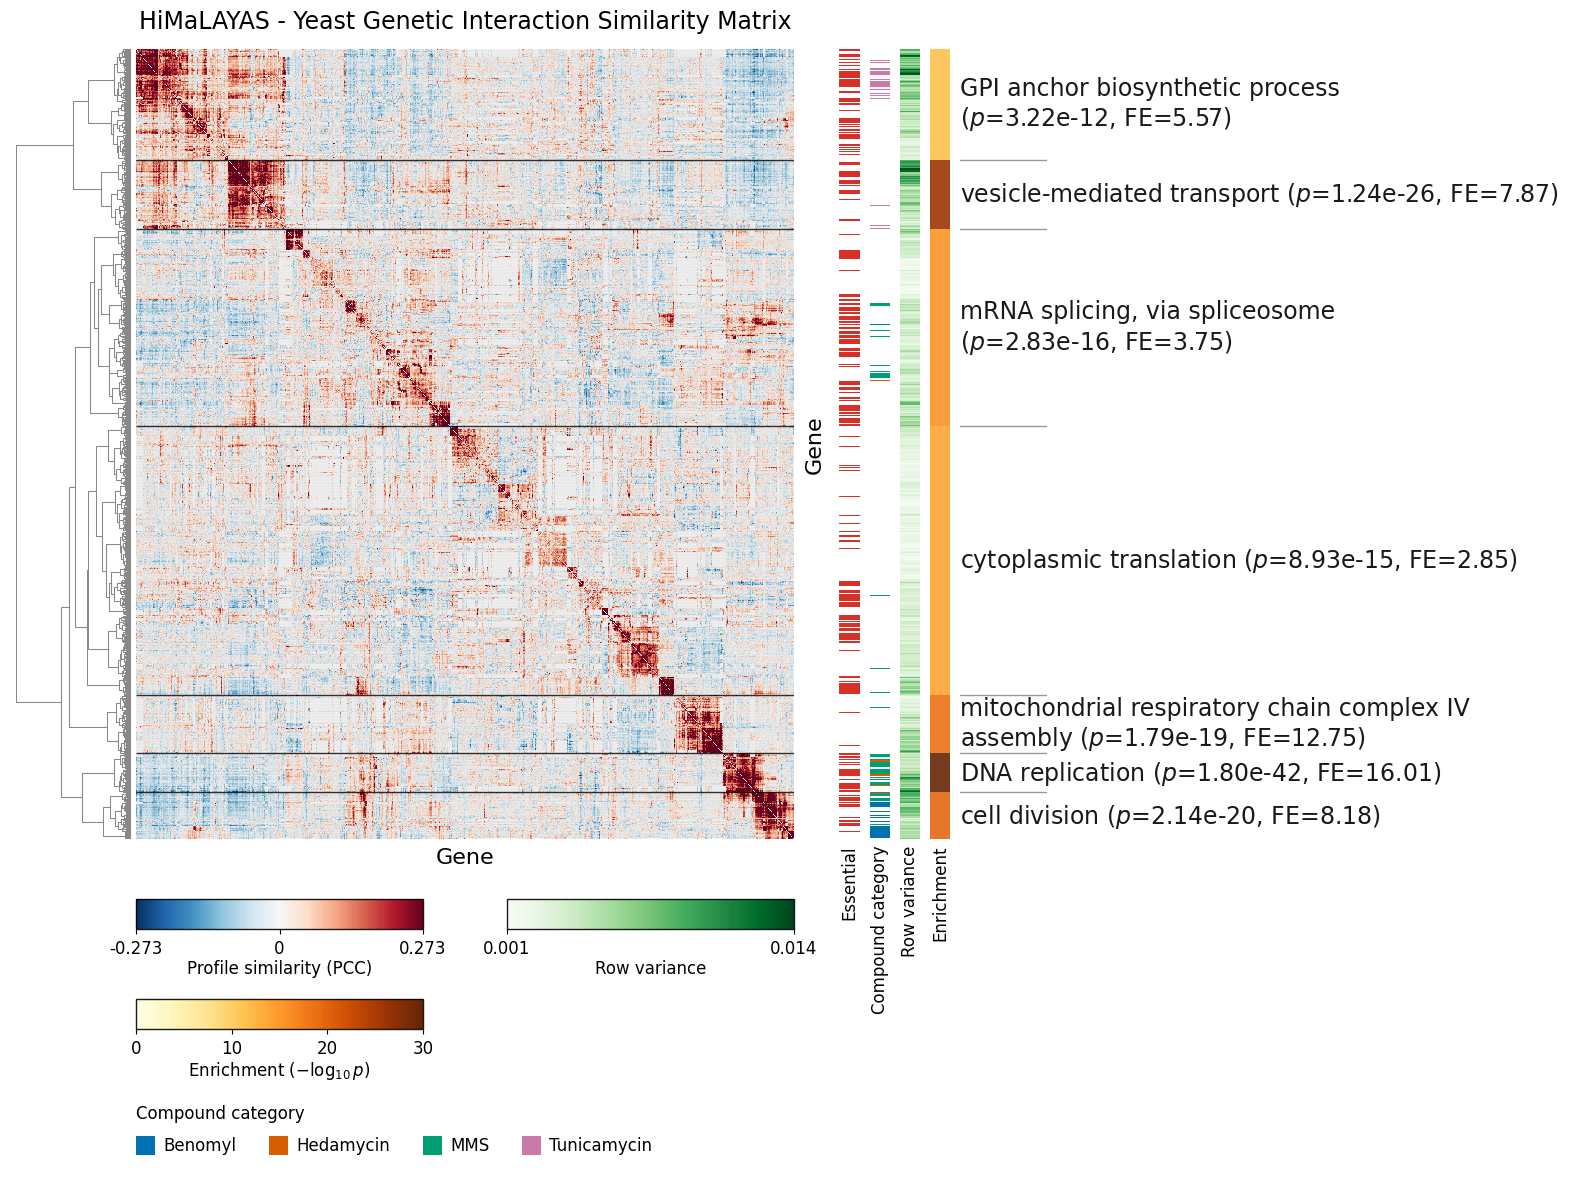

In [7]:
# Configure and render the annotated matrix

LABEL_COLOR = "black"
BACKGROUND_COLOR = "white"
FONT = "DejaVu Sans"

# Set color limits for the matrix
vals = matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

plotter = (
    Plotter(results_sig)
    # Build core layout and matrix
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        "HiMaLAYAS - Yeast Genetic Interaction Similarity Matrix",
        color=LABEL_COLOR,
        fontsize=17,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.5,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(14, 10),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=16,
        font=FONT,
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.02,
    )
    .plot_cluster_labels(
        rank_by="p",  # Set rank_by="q" to rank by q-values instead.
        label_mode="top_term",
        max_words=24,
        wrap_text=True,
        wrap_width=50,
        overflow="wrap",
        font=FONT,
        fontsize=17,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        placeholder_text="—",
        placeholder_color="#b22222",
        placeholder_alpha=0.6,
        label_fields=("label", "p", "fe"),
        label_prefix=None,
        boundary_color=LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
    )
    # Set label rails and bar-label styles
    .plot_label_bar(
        values=gene_essential_map,
        mode="categorical",
        colors=gene_essential_colors,
        width=0.04,
        left_pad=0.06,
        right_pad=0.0,
        name="essentiality",
        title="Essential",
    )
    .plot_label_bar(
        values=gene_chemgi_map,
        mode="categorical",
        colors=gene_chemgi_colors,
        missing_color="#ffffff",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="compound_target",
        title="Compound category",
    )
    .plot_label_bar(
        values=row_variance_map,
        mode="continuous",
        cmap="Greens",
        vmin=row_variance_min,
        vmax=row_variance_max,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="row_variance",
        title="Row variance",
    )
    .plot_cluster_bar(
        norm=Normalize(0, 30),
        width=0.04,
        left_pad=0.02,
        right_pad=0.00,
        name="sigbar",
        title="Enrichment",
    )
    .plot_bar_labels(
        font=FONT,
        fontsize=12,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("essentiality", "compound_target", "row_variance", "sigbar"))
    # Set colorbars for matrix, row variance, and enrichment
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="row_variance",
        cmap="Greens",
        norm=Normalize(row_variance_min, row_variance_max),
        label="Row variance",
        ticks=[row_variance_min, row_variance_max],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, 30),
        label=r"Enrichment ($-\log_{10}p$)",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.13,
        gap=0.06,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.07,
        fontsize=12,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
    # Set legend for compound target
    .add_label_legend(
        name="compound_target",
        title="Compound category",
        show_only_present=True,
        ncols=4,
        nrows=1,
        col_pad=0.05,
    )
    .plot_label_legends(
        height=0.08,
        gap=0.075,
        vpad=0.0,
        title_pad=10.0,
        swatch_scale=0.4,
        fontsize=12,
        font=FONT,
        color=LABEL_COLOR,
    )
)

plotter.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    plotter.save("outputs/quickstart_advanced_matrix.png", dpi=300, bbox_inches="tight")

---

## Condensed Dendrogram

Summarize the same hierarchy with cluster-level labels and enrichment significance.


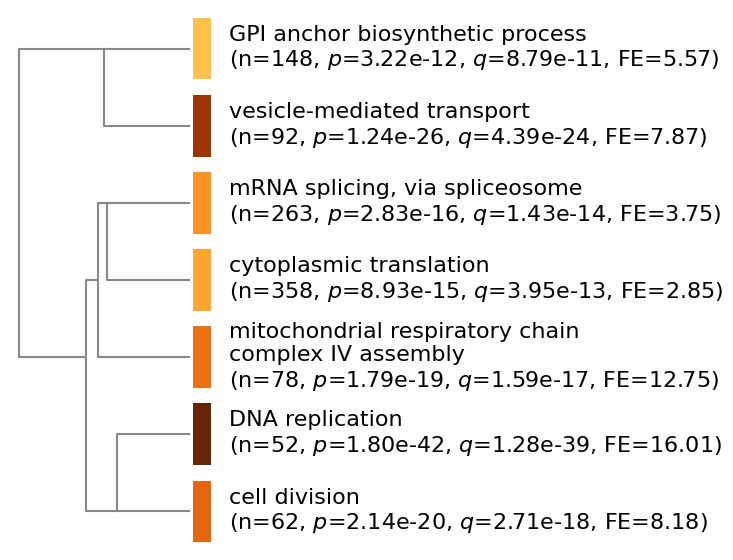

In [8]:
from himalayas.plot import plot_dendrogram_condensed

condensed = plot_dendrogram_condensed(
    results_sig,
    rank_by="p",
    label_mode="top_term",
    figsize=(3, 6),
    sigbar_cmap="YlOrBr",
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    fontsize=16,
    font=FONT,
    max_words=24,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n", "p", "q", "fe"),
    label_prefix=None,
    label_color=LABEL_COLOR,
    placeholder_text="—",
    placeholder_color="#b22222",
    placeholder_alpha=0.6,
    skip_unlabeled=False,
    label_left_pad=0.06,
    dendrogram_color="#888888",
    dendrogram_lw=1.5,
    background_color=BACKGROUND_COLOR,
)

condensed.show()

if SAVE_FIGURES:
    condensed.save("outputs/quickstart_advanced_condensed.png", dpi=300, bbox_inches="tight")

---

## Nested Zoom Workflow

Zoom into a single cluster, rerun clustering and enrichment at lower dendrogram depth, and plot the zoomed view.


In [9]:
# Define a helper to run zoomed cluster analysis


def run_zoom_analysis(
    *,
    results,
    cluster_id,
    annotations,
    linkage_threshold,
    linkage_method="ward",
    linkage_metric="euclidean",
    background_matrix,
    optimal_ordering=True,
    min_cluster_size=6,
    min_overlap=2,
    qval_cutoff=0.05,
):
    """
    Runs a localized re-clustering and GO BP enrichment analysis within a selected cluster and
    returns zoomed matrix, results, and filtered results.
    """
    zoom_view = results.subset(cluster=cluster_id)
    zoom_matrix = zoom_view.matrix
    zoom_annotations = annotations.rebind(zoom_matrix)

    zoom_analysis = (
        Analysis(zoom_matrix, zoom_annotations)
        .cluster(
            linkage_method=linkage_method,
            linkage_metric=linkage_metric,
            linkage_threshold=linkage_threshold,
            optimal_ordering=optimal_ordering,
            min_cluster_size=min_cluster_size,
        )
        .enrich(min_overlap=min_overlap, background=background_matrix)
        .finalize(col_cluster=True)
    )
    zoom_results = zoom_analysis.results
    zoom_results_sig = zoom_results.filter(f"qval <= {qval_cutoff}")
    return zoom_matrix, zoom_results, zoom_results_sig

### Plot the Zoomed Matrix

Run the zoom analysis for a cluster, then render a compact figure using the same plotting pipeline.


/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 427/604 annotations after matrix filtering (size or overlap constraints)
  warn(


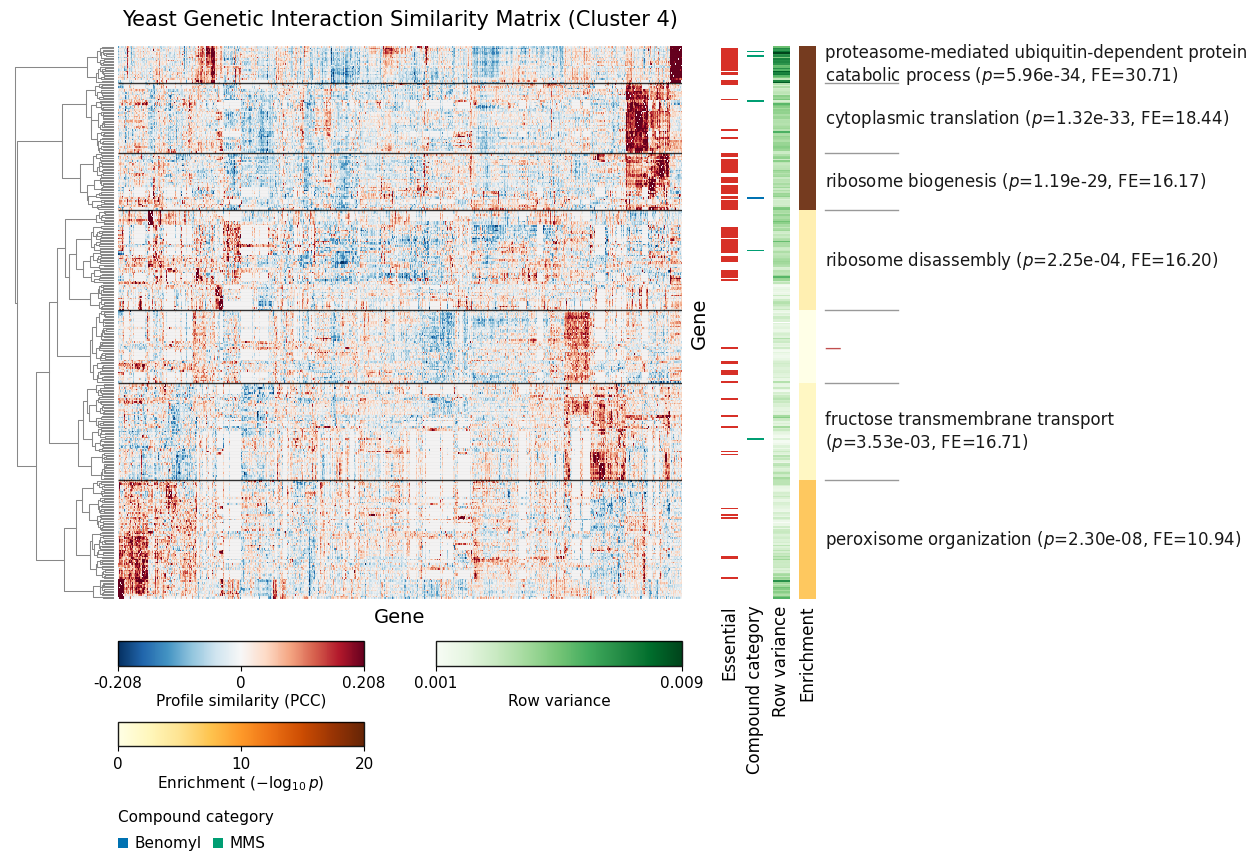

In [10]:
# Run zoomed analysis and render the zoomed plot

CLUSTER_ID = 4
ZOOM_LINKAGE_THRESHOLD = 7.5

# Get zoomed matrix, results, and significant results for the selected cluster ID and parameters
zoom_matrix, zoom_results, zoom_results_sig = run_zoom_analysis(
    results=results,
    cluster_id=CLUSTER_ID,
    annotations=annotations,
    linkage_threshold=ZOOM_LINKAGE_THRESHOLD,
    linkage_method=LINKAGE_METHOD,
    linkage_metric=LINKAGE_METRIC,
    optimal_ordering=OPTIMAL_ORDERING,
    background_matrix=matrix,
    min_cluster_size=6,
)
# Set color limits for the zoomed matrix
vals = zoom_matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))
# Calculate row variance for the zoomed matrix to use as a continuous rail in the zoomed plot
zoom_row_variance_map = zoom_matrix.df.var(axis=1).astype(float).to_dict()
zoom_row_variance_values = np.fromiter(zoom_row_variance_map.values(), dtype=float)
zoom_row_variance_min = float(np.nanmin(zoom_row_variance_values))
zoom_row_variance_max = float(np.nanmax(zoom_row_variance_values))

plotter = (
    Plotter(zoom_results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        f"Yeast Genetic Interaction Similarity Matrix (Cluster {CLUSTER_ID})",
        color=LABEL_COLOR,
        fontsize=15,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.5,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(12, 7),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=14,
        font=FONT,
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.02,
    )
    .plot_cluster_labels(
        rank_by="p",
        label_mode="top_term",
        max_words=24,
        wrap_text=True,
        wrap_width=50,
        overflow="wrap",
        font=FONT,
        fontsize=12,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        placeholder_text="—",
        placeholder_color="#b22222",
        placeholder_alpha=0.8,
        label_fields=("label", "p", "fe"),
        label_prefix=None,
        boundary_color=LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
    )
    .plot_label_bar(
        values=gene_essential_map,
        mode="categorical",
        colors=gene_essential_colors,
        left_pad=0.06,
        width=0.04,
        right_pad=0.0,
        name="essentiality",
        title="Essential",
    )
    .plot_label_bar(
        values=gene_chemgi_map,
        mode="categorical",
        colors=gene_chemgi_colors,
        missing_color="#ffffff",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="compound_target",
        title="Compound category",
    )
    .plot_label_bar(
        values=zoom_row_variance_map,
        mode="continuous",
        cmap="Greens",
        vmin=zoom_row_variance_min,
        vmax=zoom_row_variance_max,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="row_variance",
        title="Row variance",
    )
    .plot_cluster_bar(
        norm=Normalize(0, 20),
        name="sigbar",
        title="Enrichment",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
    )
    .plot_bar_labels(
        font=FONT,
        fontsize=12,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("essentiality", "compound_target", "row_variance", "sigbar"))
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="row_variance",
        cmap="Greens",
        norm=Normalize(zoom_row_variance_min, zoom_row_variance_max),
        label="Row variance",
        ticks=[zoom_row_variance_min, zoom_row_variance_max],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, 20),
        label=r"Enrichment ($-\log_{10}p$)",
        ticks=[0, 10, 20],
    )
    .plot_colorbars(
        ncols=2,
        height=0.15,
        gap=0.06,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.08,
        fontsize=11,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
    .add_label_legend(
        name="compound_target",
        title="Compound category",
        show_only_present=True,
    )
    .plot_label_legends(
        height=0.06,
        gap=0.09,
        vpad=0.008,
        title_pad=10.0,
        swatch_scale=0.75,
        fontsize=11,
        font=FONT,
        color=LABEL_COLOR,
    )
)

plotter.show()

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 587/604 annotations after matrix filtering (size or overlap constraints)
  warn(


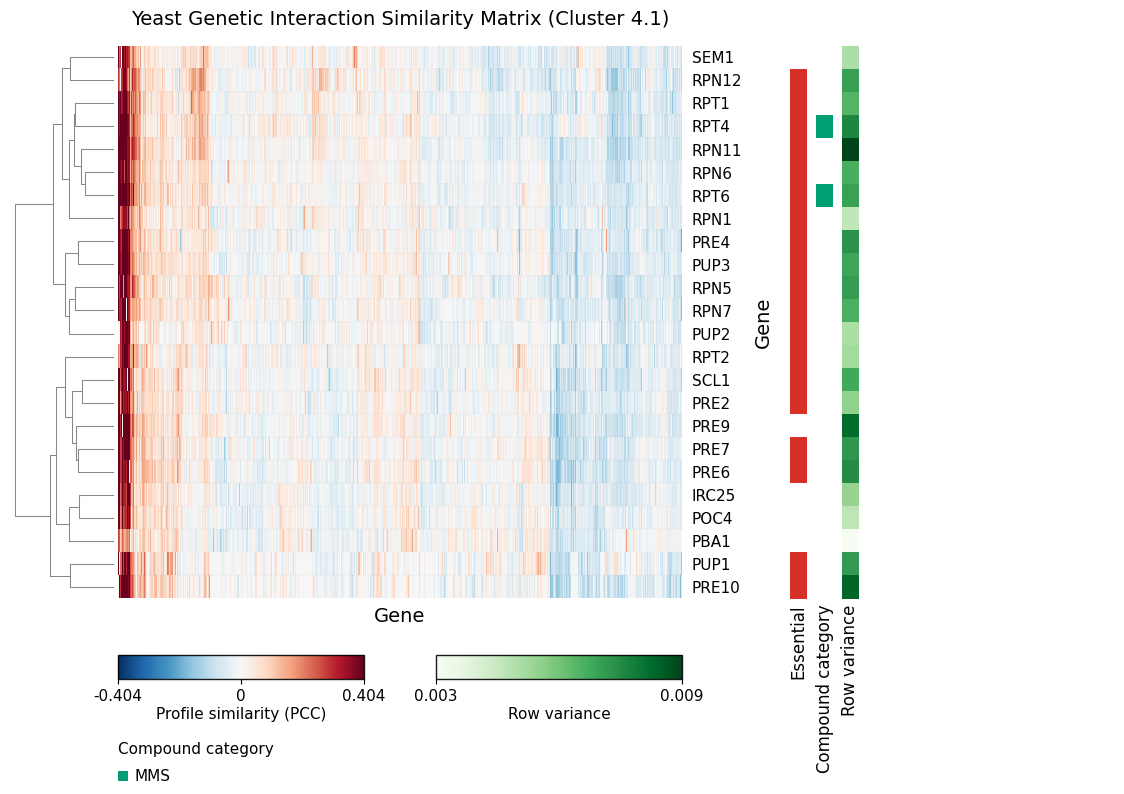

In [11]:
# Run nested zoom analysis and render the subcluster plot

PARENT_CLUSTER_ID = 4
SUBCLUSTER_ID = 1
SUBCLUSTER_LINKAGE_THRESHOLD = 4
SUBCLUSTER_PATH = f"{PARENT_CLUSTER_ID}.{SUBCLUSTER_ID}"

# Get subcluster matrix, results, and significant results for the selected zoomed cluster ID and parameters
subcluster_matrix, subcluster_results, subcluster_results_sig = run_zoom_analysis(
    results=zoom_results,
    cluster_id=SUBCLUSTER_ID,
    annotations=annotations,
    linkage_threshold=SUBCLUSTER_LINKAGE_THRESHOLD,
    linkage_method=LINKAGE_METHOD,
    linkage_metric=LINKAGE_METRIC,
    optimal_ordering=OPTIMAL_ORDERING,
    min_cluster_size=2,
    background_matrix=matrix,
)
# Set color limits for the subcluster matrix
vals = subcluster_matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))
# Calculate row variance for the subcluster matrix to use as a continuous rail in the subcluster plot
subcluster_row_variance_map = subcluster_matrix.df.var(axis=1).astype(float).to_dict()
subcluster_row_variance_values = np.fromiter(subcluster_row_variance_map.values(), dtype=float)
subcluster_row_variance_min = float(np.nanmin(subcluster_row_variance_values))
subcluster_row_variance_max = float(np.nanmax(subcluster_row_variance_values))

plotter = (
    Plotter(subcluster_results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        f"Yeast Genetic Interaction Similarity Matrix (Cluster {SUBCLUSTER_PATH})",
        color=LABEL_COLOR,
        fontsize=14,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.5,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=0,
        figsize=(12, 7),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=14,
        font=FONT,
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.06,
    )
    .plot_row_ticks(
        max_labels=60,
        fontsize=11,
        position="right",
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.02,
    )
    .plot_label_bar(
        values=gene_essential_map,
        mode="categorical",
        colors=gene_essential_colors,
        left_pad=0.22,
        width=0.04,
        right_pad=0.0,
        name="essentiality",
        title="Essential",
    )
    .plot_label_bar(
        values=gene_chemgi_map,
        mode="categorical",
        colors=gene_chemgi_colors,
        missing_color="#ffffff",
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="compound_target",
        title="Compound category",
    )
    .plot_label_bar(
        values=subcluster_row_variance_map,
        mode="continuous",
        cmap="Greens",
        vmin=subcluster_row_variance_min,
        vmax=subcluster_row_variance_max,
        width=0.04,
        left_pad=0.02,
        right_pad=0.0,
        name="row_variance",
        title="Row variance",
    )
    .plot_bar_labels(
        font=FONT,
        fontsize=12,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("essentiality", "compound_target", "row_variance"))
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="row_variance",
        cmap="Greens",
        norm=Normalize(subcluster_row_variance_min, subcluster_row_variance_max),
        label="Row variance",
        ticks=[subcluster_row_variance_min, subcluster_row_variance_max],
    )
    .plot_colorbars(
        ncols=2,
        height=0.035,
        gap=0.08,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.09,
        fontsize=11,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
    .add_label_legend(
        name="compound_target",
        title="Compound category",
        show_only_present=True,
    )
    .plot_label_legends(
        height=0.06,
        gap=0.09,
        vpad=0.008,
        title_pad=10.0,
        swatch_scale=0.75,
        fontsize=11,
        font=FONT,
        color=LABEL_COLOR,
    )
)

plotter.show()